# Projected PCA

In [1]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

import os

from plm_seq_utils import letters_to_nums, sequences_from_fasta, one_hot_seq_batch
from plm_PCA_func import plot_projected_pca, plot_pca_of_sequences

<string>:16: SyntaxWarning: invalid escape sequence '\{'
<string>:16: SyntaxWarning: invalid escape sequence '\{'
<string>:29: SyntaxWarning: invalid escape sequence '\{'
<>:16: SyntaxWarning: invalid escape sequence '\{'
<>:16: SyntaxWarning: invalid escape sequence '\{'
<>:16: SyntaxWarning: invalid escape sequence '\C'
<>:29: SyntaxWarning: invalid escape sequence '\{'
<>:29: SyntaxWarning: invalid escape sequence '\C'
<string>:16: SyntaxWarning: invalid escape sequence '\{'
<string>:16: SyntaxWarning: invalid escape sequence '\{'
<string>:29: SyntaxWarning: invalid escape sequence '\{'
<>:16: SyntaxWarning: invalid escape sequence '\{'
<>:16: SyntaxWarning: invalid escape sequence '\{'
<>:16: SyntaxWarning: invalid escape sequence '\C'
<>:29: SyntaxWarning: invalid escape sequence '\{'
<>:29: SyntaxWarning: invalid escape sequence '\C'
C:\Users\youss\AppData\Local\Temp\ipykernel_900\2102076540.py:16: SyntaxWarning: invalid escape sequence '\{'
  output_file = cwd + f'\CODE\Attentio

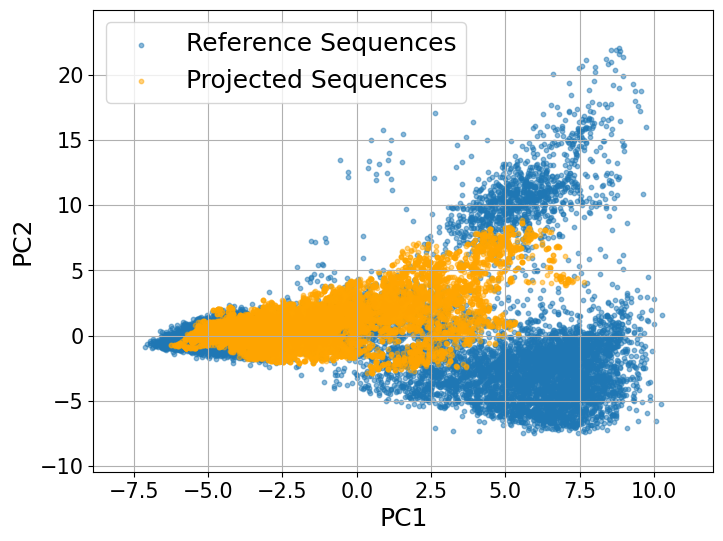

In [2]:
"""
    One-hot encode AA sequences - plm generated and true
"""
# -------------- Load generated sequences ----------------
file_dir='generated_sequences'
#filename = 'gen_seqs_w_init_seq_Ns40000_r0.1'
filename = 'generated_sequences_randinit_40000'
#file_dir = 'mc_generated_sequences'
#filename = 'mc_gen_seqs_w_init_seq_Ns100000_r0.1'

#cwd = '/Users/marzioformica/Desktop/EPFL/Master/MA2/Labo/my_project/PLM-gen-DCA/Attention-DCA-main'
cwd=r'C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\git_test\PLM-gen-DCA\Attention-DCA-main'

# Load the generated sequences
#output_file = cwd + f'/CODE/AttentionDCA_python/src/PLM/{file_dir}/{filename}.npy'
output_file = cwd + f'\CODE\AttentionDCA_python\src\PLM\{file_dir}\{filename}.npy'
gen_sequences = np.load(output_file)
saved_seq = gen_sequences.copy()
Ni = 10000
Nf = 30000
gen_sequences = gen_sequences[Ni:Nf]


# -------------- Load train sequences ----------------
# Load train sequences
family = 'jdoms_bacteria_train2'
#filename = cwd + f'/CODE/DataAttentionDCA/jdoms/{family}.fasta'

filename = cwd + f'\CODE\DataAttentionDCA\jdoms\{family}.fasta'

train_sequences = sequences_from_fasta(filename)
train_sequences_num = [letters_to_nums(seq) for seq in train_sequences]


plot_projected_pca(
    sequences_reference=train_sequences,
    sequences_to_project=gen_sequences,
    title="PCA Projection: Train vs Generated"
)

Loading: C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\git_test\PLM-gen-DCA\Attention-DCA-main\CODE\AttentionDCA_python\src\PLM\gill_generated_sequences\gill_gen_seqs_w_init_seq_Ns30000_r0.3_after_mod.npy


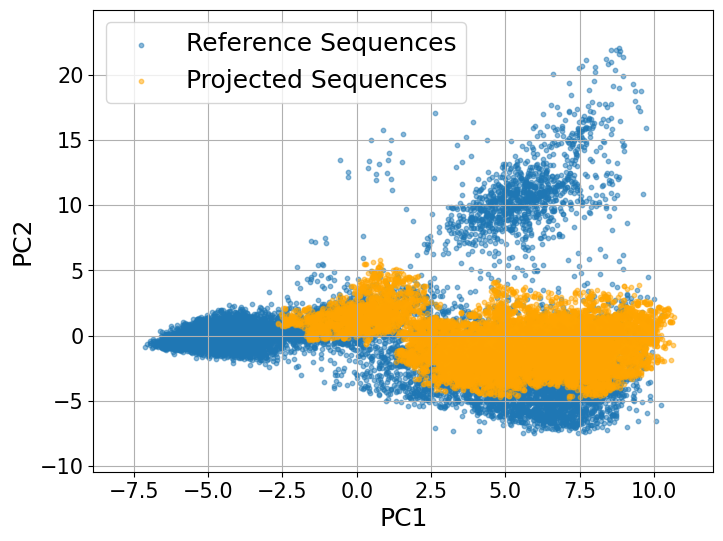

Saved PCA plot to: c:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\git_test\PLM-gen-DCA\Attention-DCA-main\CODE\AttentionDCA_python\src\PLM\results\PCA_plots\gillespie/gill_gen_seqs_w_init_seq_Ns30000_r0.3_after_mod.png


In [4]:
file_map = {
    #'generated_sequences_randinit_40000': 'generated_sequences',
    #'gen_seqs_w_init_seq_Ns40000_r0.1': 'generated_sequences',
    #'mc_generated_sequences_randinit_300000': 'mc_generated_sequences',
    #'mc_gen_seqs_w_init_seq_Ns100000_r0.1': 'mc_generated_sequences',
    'gill_gen_seqs_w_init_seq_Ns30000_r0.3_after_mod':'gill_generated_sequences'
    #'gill_generated_sequences_randinit_20000':'gill_generated_sequences'
}


for filename, dir in file_map.items():
    cwd = os.getcwd()

    if dir=='generated_sequences':
        save_subdir = 'plm' 
    elif dir=='mc_generated_sequences':
        save_subdir='mc'
    elif dir=='gill_generated_sequences':
        save_subdir='gillespie'

    save_path = os.path.join(cwd, 'results', 'PCA_plots', save_subdir)
    os.makedirs(save_path, exist_ok=True)
    cwd=r'C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\git_test\PLM-gen-DCA\Attention-DCA-main'

    #cwd = '/Users/marzioformica/Desktop/EPFL/Master/MA2/Labo/my_project/PLM-gen-DCA/Attention-DCA-main'
    output_file = os.path.join(cwd, 'CODE', 'AttentionDCA_python', 'src', 'PLM', dir, f'{filename}.npy')

    if os.path.exists(output_file):
        print(f"Loading: {output_file}")
        gen_sequences = np.load(output_file)
        # proceed with PCA or other processing...
    else:
        print(f"File not found: {output_file}")
    start_idx = 1000
    num_samples = len(train_sequences)
    gen_sequences = gen_sequences[start_idx:15000]
    
    # Uniformly sample indices
    indices = np.linspace(0, len(gen_sequences) - 1, num_samples, dtype=int)
    gen_sequences = gen_sequences[indices]
    save_name = save_path + f'/{filename}.png'
    plot_projected_pca(
        sequences_reference=train_sequences,
        sequences_to_project=gen_sequences,
        title=f"PCA Projection: Train vs {dir}",
        max_pot=21, save_path=save_name
    )
    print(f"Saved PCA plot to: {save_name}")